<a href="https://colab.research.google.com/github/i253190-Qaiser-Iqbal/mvc-mlp-25i-3190/blob/main/Task7_MLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Iteration Table (Task 4C):
Iter | w1_11 w1_12 w1_13 w1_21 w1_22 w1_23 | w2_11 w2_21 w2_31 | b1_1 b1_2 b1_3 | b2 | Loss
1 | 0.5905 0.4002 0.1895 0.2804 -0.7210 0.7793 | 0.1803 -0.2557 -0.1991 | -0.6788 0.7490 -0.6414 | 0.0240 | 0.2521
2 | 0.5910 0.4006 0.1891 0.2807 -0.7217 0.7788 | 0.1883 -0.2447 -0.1907 | -0.6778 0.7483 -0.6425 | 0.0429 | 0.2512
3 | 0.5913 0.4011 0.1888 0.2809 -0.7223 0.7784 | 0.1945 -0.2364 -0.1841 | -0.6769 0.7479 -0.6434 | 0.0576 | 0.2506
4 | 0.5917 0.4017 0.1886 0.2811 -0.7227 0.7781 | 0.1992 -0.2301 -0.1791 | -0.6761 0.7476 -0.6441 | 0.0691 | 0.2503
5 | 0.5919 0.4022 0.1885 0.2812 -0.7231 0.7779 | 0.2029 -0.2254 -0.1752 | -0.6755 0.7475 -0.6447 | 0.0781 | 0.2501


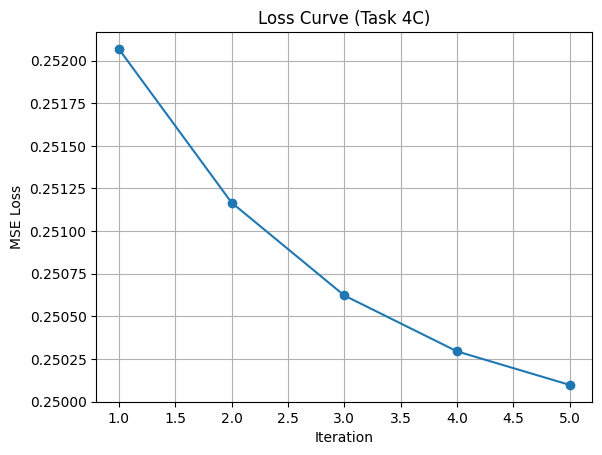

In [1]:
# =========================================================
# Multi-Layer Perceptron (MLP) Project – Task 7
# Student Name: Qaiser Iqbal
# Roll No: 25I-3190
# =========================================================

import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Sigmoid activation functions
# -----------------------------
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

# -----------------------------
# Mean Squared Error
# -----------------------------
def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

# -----------------------------
# Input and output (XOR example)
# -----------------------------
X = np.array([[0, 0],
              [0, 1],
              [1, 0],
              [1, 1]])
y = np.array([[0],
              [1],
              [1],
              [0]])

# -----------------------------
# Unique weights and biases (replace with YOUR assigned values)
# -----------------------------
w1 = np.array([[0.59, 0.4, 0.19],   # Row1: Input1 connections
               [0.28, -0.72, 0.78]]) # Row2: Input2 connections
b1 = np.array([[-0.68, 0.75, -0.64]]) # Biases for hidden layer

w2 = np.array([[0.17], [-0.27], [-0.21]]) # Hidden to output weights
b2 = np.array([[0.0]])                    # Output bias

# -----------------------------
# Hyperparameters
# -----------------------------
lr = 0.5
iterations = 5

# -----------------------------
# To store loss values
# -----------------------------
loss_history = []

# -----------------------------
# Task 4C – Iteration Table
# -----------------------------
print("Iteration Table (Task 4C):")
print("Iter | w1_11 w1_12 w1_13 w1_21 w1_22 w1_23 | w2_11 w2_21 w2_31 | b1_1 b1_2 b1_3 | b2 | Loss")

for i in range(iterations):
    # -------- Forward Pass --------
    hidden_input = np.dot(X, w1) + b1
    hidden_output = sigmoid(hidden_input)
    final_input = np.dot(hidden_output, w2) + b2
    final_output = sigmoid(final_input)

    # -------- Loss Calculation --------
    loss = mse(y, final_output)
    loss_history.append(loss)

    # -------- Backpropagation --------
    error = y - final_output
    d_output = error * sigmoid_derivative(final_output)
    error_hidden = d_output.dot(w2.T)
    d_hidden = error_hidden * sigmoid_derivative(hidden_output)

    # -------- Update Weights & Biases --------
    w2 += hidden_output.T.dot(d_output) * lr
    b2 += np.sum(d_output, axis=0, keepdims=True) * lr
    w1 += X.T.dot(d_hidden) * lr
    b1 += np.sum(d_hidden, axis=0, keepdims=True) * lr

    # -------- Print Iteration Table --------
    print(f"{i+1} | "
          f"{w1[0,0]:.4f} {w1[0,1]:.4f} {w1[0,2]:.4f} "
          f"{w1[1,0]:.4f} {w1[1,1]:.4f} {w1[1,2]:.4f} | "
          f"{w2[0,0]:.4f} {w2[1,0]:.4f} {w2[2,0]:.4f} | "
          f"{b1[0,0]:.4f} {b1[0,1]:.4f} {b1[0,2]:.4f} | "
          f"{b2[0,0]:.4f} | {loss:.4f}")

# -----------------------------
# Plot Loss Curve
# -----------------------------
plt.plot(range(1, iterations+1), loss_history, marker='o')
plt.title("Loss Curve (Task 4C)")
plt.xlabel("Iteration")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()